# Financial Risk Analysis with Python - Barclays

### Dataset:
Barclays Financial Transactional Data

### Project Objective

The objective of this project is to analyze Barclays customers' financial transaction behavior, identify financial risks, build customer profiles, and generate meaningful business insights using Python. The project includes data cleaning, descriptive analysis, customer segmentation, risk identification, visualization, and hypothesis testing to support better financial decision-making.

# Task 1: Data Cleaning and Formatting

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("Barclays Financial Transactional Data - barclays.csv")

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


### Display First Five Records

In [4]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


### Check Dataset Dimensions

In [5]:
df.shape

(800, 15)

### Display Column Names

In [6]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='str')

### Check Data Types and Dataset Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    str    
 2   AccountID          800 non-null    str    
 3   AccountType        800 non-null    str    
 4   TransactionType    800 non-null    str    
 5   Product            800 non-null    str    
 6   Firm               800 non-null    str    
 7   Region             800 non-null    str    
 8   Manager            800 non-null    str    
 9   TransactionDate    800 non-null    str    
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 149.9 KB


### Generate Descriptive Statistics

In [8]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,101.261250,53695.086727,72920.295572,0.472623,583.485000,122.306250
std,57.219779,30115.644050,34005.837334,0.232112,156.661453,66.564563
min,1.000000,-59669.075480,-30766.906970,-0.380361,305.000000,6.000000
25%,54.750000,33334.555715,49949.249088,0.315380,452.750000,64.000000
50%,100.000000,52765.641760,72252.815065,0.469889,591.500000,122.500000
75%,154.000000,74158.869990,97290.666368,0.623438,718.500000,175.000000
max,199.000000,166083.829600,184008.258800,1.257012,849.000000,239.000000


### Check Missing Values

In [9]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

### Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

### Remove Special Characters from Financial Fields

Financial columns should contain only numeric values. Any commas, currency symbols, or spaces will be removed before converting the values into numeric format.

In [11]:
financial_columns = ["TransactionAmount", "AccountBalance"]

for col in financial_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Financial fields cleaned successfully.")

Financial fields cleaned successfully.


### Validate and Format Date Column

In [12]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    dayfirst=True,
    errors="coerce"
)
print("TransactionDate formatted successfully.")

df["TransactionDate"].head()


TransactionDate formatted successfully.


0   2024-01-08
1   2023-12-17
2   2024-05-22
3   2023-12-24
4   2023-01-15
Name: TransactionDate, dtype: datetime64[us]

### Standardize Account Types

Account type names are standardized by removing extra spaces and converting them into title case to maintain consistency.

In [13]:
df["AccountType"] = (
    df["AccountType"]
    .str.strip()
    .str.title()
)

df["AccountType"].unique()

<ArrowStringArray>
['Savings', 'Credit', 'Loan', 'Current']
Length: 4, dtype: str

### Standardize Transaction Categories

Transaction categories are standardized by removing extra spaces and converting them into title case.

In [14]:
df["TransactionType"] = (
    df["TransactionType"]
    .str.strip()
    .str.title()
)

df["TransactionType"].unique()

<ArrowStringArray>
['Deposit', 'Payment', 'Withdrawal', 'Transfer']
Length: 4, dtype: str

#### Data Types After Cleaning

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    str           
 2   AccountID          800 non-null    str           
 3   AccountType        800 non-null    str           
 4   TransactionType    800 non-null    str           
 5   Product            800 non-null    str           
 6   Firm               800 non-null    str           
 7   Region             800 non-null    str           
 8   Manager            800 non-null    str           
 9   TransactionDate    800 non-null    datetime64[us]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMonths       80

In [16]:
df.to_csv(
    "Output/Cleaned_Barclays_Data.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Task 1 Summary

- Financial fields were successfully cleaned and converted into numeric format.
- Transaction dates were converted into datetime format.
- Account types and transaction categories were standardized.
- Missing values and duplicate records were checked.
- The cleaned dataset was saved for further analysis.

# Task 2: Descriptive Transactional Analysis

### Business Rule Used

The dataset does not explicitly contain "Credit" and "Debit" transaction labels.

Therefore, the following business rule has been applied throughout this project:

#### Credit Transactions
- Deposit

#### Debit Transactions
- Withdrawal
- Payment
- Transfer

This business rule has been consistently used for all transaction analysis.

### Create Month and Year Columns

In [ ]:
df["Month"] = df["TransactionDate"].dt.to_period("M")

df["Year"] = df["TransactionDate"].dt.year

print("Month and Year columns created successfully.")

df[["TransactionDate", "Month", "Year"]].head()

Month and Year columns created successfully.


,TransactionDate,Month,Year
0,2024-01-08,2024-01,2024
1,2023-12-17,2023-12,2023
2,2024-05-22,2024-05,2024
3,2023-12-24,2023-12,2023
4,2023-01-15,2023-01,2023


### Create Transaction Category (Credit/Debit)

In [ ]:
credit_transactions = ["Deposit"]

debit_transactions = [
    "Withdrawal",
    "Payment",
    "Transfer"
]


def classify_transaction(transaction):

    if transaction in credit_transactions:
        return "Credit"

    elif transaction in debit_transactions:
        return "Debit"

    else:
        return "Other"


df["TransactionCategory"] = df["TransactionType"].apply(classify_transaction)

print("Transaction categories created successfully.")

df["TransactionCategory"].value_counts()

Transaction categories created successfully.


TransactionCategory
Debit     614
Credit    186
Name: count, dtype: int64

### Calculate Monthly Credit Summary


In [ ]:
monthly_credit = (
    df[df["TransactionCategory"] == "Credit"]
    .groupby("Month")["TransactionAmount"]
    .sum()
    .reset_index()
)

monthly_credit

,Month,TransactionAmount
0,2023-01,569469.355020
1,2023-02,521830.583465
2,2023-03,342372.905660
3,2023-04,146580.612610
4,2023-05,568697.316343
5,2023-06,488374.114340
6,2023-07,419545.008620
7,2023-08,547258.559443
8,2023-09,856750.211760
9,2023-10,582604.365887


In [ ]:
monthly_credit.to_csv(
    "Output/Monthly_Credit_Summary.csv",
    index=False
)

print("Monthly Credit Summary saved successfully.")

Monthly Credit Summary saved successfully.


### Monthly Debit Summary

In [ ]:
monthly_debit = (
    df[df["TransactionCategory"] == "Debit"]
    .groupby("Month")["TransactionAmount"]
    .sum()
    .reset_index()
)

monthly_debit

,Month,TransactionAmount
0,2023-01,2.216844e+06
1,2023-02,2.009549e+06
2,2023-03,1.159596e+06
3,2023-04,1.551606e+06
4,2023-05,2.568691e+06
5,2023-06,2.415617e+06
6,2023-07,1.765712e+06
7,2023-08,2.359400e+06
8,2023-09,1.643812e+06
9,2023-10,2.932289e+06


In [ ]:
monthly_debit.to_csv(
    "Output/Monthly_Debit_Summary.csv",
    index=False
)

print("Monthly Debit Summary saved successfully.")

Monthly Debit Summary saved successfully.


### Monthly Net Transaction Volume

Net Transaction Volume = Total Credits − Total Debits

In [ ]:
monthly_summary = pd.merge(
    monthly_credit,
    monthly_debit,
    on="Month",
    how="outer",
    suffixes=("_Credit", "_Debit")
)

monthly_summary = monthly_summary.fillna(0)

monthly_summary["NetTransaction"] = (
    monthly_summary["TransactionAmount_Credit"]
    -
    monthly_summary["TransactionAmount_Debit"]
)

monthly_summary

,Month,TransactionAmount_Credit,TransactionAmount_Debit,NetTransaction
0,2023-01,569469.355020,2.216844e+06,-1.647375e+06
1,2023-02,521830.583465,2.009549e+06,-1.487719e+06
2,2023-03,342372.905660,1.159596e+06,-8.172234e+05
3,2023-04,146580.612610,1.551606e+06,-1.405025e+06
4,2023-05,568697.316343,2.568691e+06,-1.999993e+06
5,2023-06,488374.114340,2.415617e+06,-1.927243e+06
6,2023-07,419545.008620,1.765712e+06,-1.346167e+06
7,2023-08,547258.559443,2.359400e+06,-1.812142e+06
8,2023-09,856750.211760,1.643812e+06,-7.870617e+05
9,2023-10,582604.365887,2.932289e+06,-2.349685e+06


In [ ]:
monthly_summary.to_csv(
    "Output/Monthly_Transaction_Summary.csv",
    index=False
)

print("Monthly Transaction Summary saved successfully.")

Monthly Transaction Summary saved successfully.


The monthly transaction summary indicates that debit transactions are higher than credit transactions in every month. As a result, the net transaction volume remains negative throughout the analysis period. This suggests that customers, on average, are spending or transferring more money than they are depositing during these months.

### Calculate Yearly Transaction Summary


In [ ]:
yearly_summary = (
    df.groupby(
        ["Year", "TransactionCategory"]
    )["TransactionAmount"]
    .sum()
    .unstack(fill_value=0)
)

yearly_summary["NetTransaction"] = (
    yearly_summary["Credit"]
    -
    yearly_summary["Debit"]
)

yearly_summary

TransactionCategory,Credit,Debit,NetTransaction
Year,,,
2023,6.401583e+06,2.399144e+07,-1.758985e+07
2024,3.285179e+06,9.277869e+06,-5.992690e+06


In [ ]:
yearly_summary.to_csv(
    "Output/Yearly_Transaction_Summary.csv"
)

print("Yearly summary saved successfully.")

Yearly summary saved successfully.


### Monthly Credit vs Debit Trend

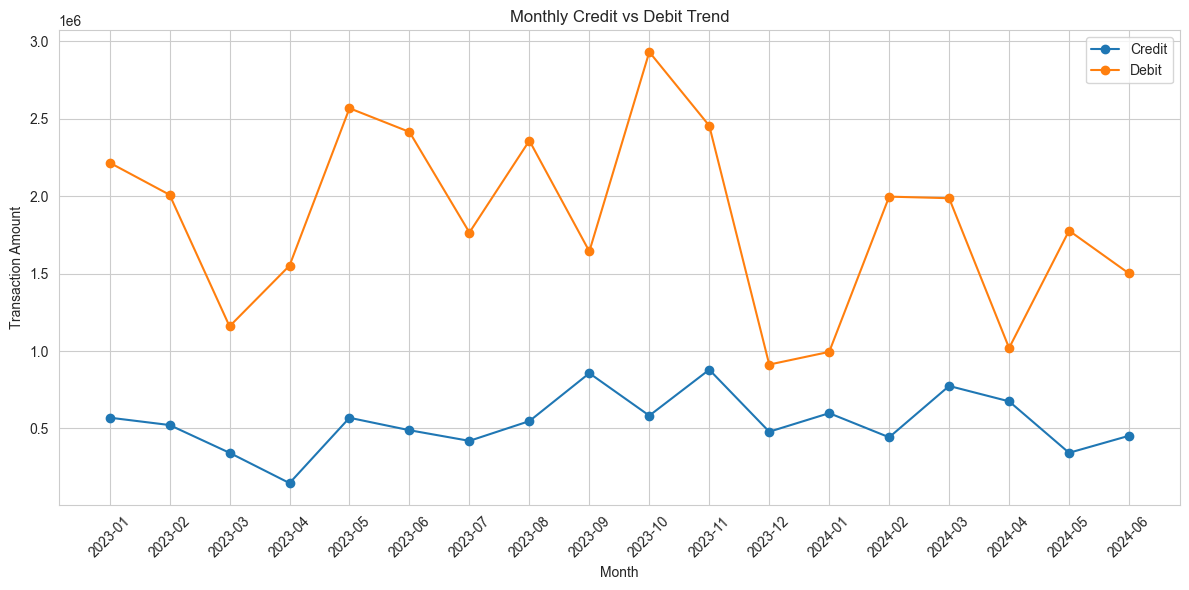

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_summary["Month"].astype(str),
    monthly_summary["TransactionAmount_Credit"],
    marker="o",
    label="Credit"
)

plt.plot(
    monthly_summary["Month"].astype(str),
    monthly_summary["TransactionAmount_Debit"],
    marker="o",
    label="Debit"
)

plt.xticks(rotation=45)

plt.title("Monthly Credit vs Debit Trend")

plt.xlabel("Month")

plt.ylabel("Transaction Amount")

plt.legend()

plt.tight_layout()

plt.savefig(
    "Images/monthly_credit_vs_debit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The graph compares monthly credit and debit transaction trends. It helps identify periods where customer spending exceeds deposits and highlights overall transaction behavior throughout the analysis period.

### Top Performing Accounts Based on Net Inflow

Net inflow is calculated as the sum of all transaction amounts for each account. Accounts with the highest positive net inflow are considered the top-performing accounts.

In [ ]:
top_accounts = (
    df.groupby("AccountID")["TransactionAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_accounts

,AccountID,TransactionAmount
0,ACC54589,720103.595590
1,ACC92558,645089.102250
2,ACC49422,564943.533450
3,ACC80131,556260.453470
4,ACC42710,552578.283770
5,ACC19178,538885.526270
6,ACC83581,507631.685320
7,ACC94203,493355.012822
8,ACC77773,476188.652680
9,ACC32890,450092.904840


In [ ]:
top_accounts.to_csv(
    "Output/Top_Performing_Accounts.csv",
    index=False
)

print("Top performing accounts saved successfully.")

Top performing accounts saved successfully.


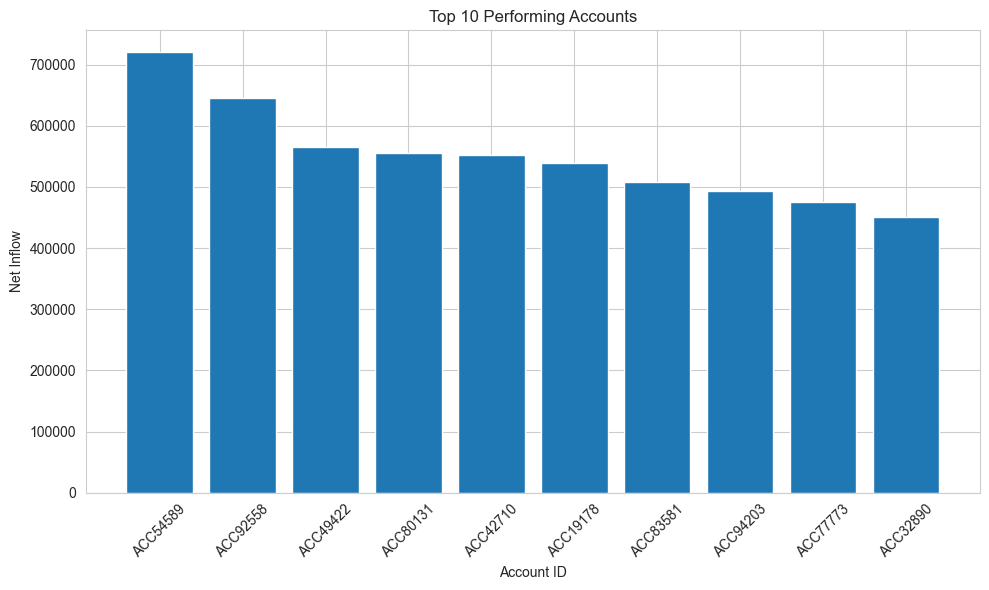

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    top_accounts["AccountID"],
    top_accounts["TransactionAmount"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Performing Accounts")

plt.xlabel("Account ID")

plt.ylabel("Net Inflow")

plt.tight_layout()

plt.savefig(
    "Images/top_performing_accounts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


These accounts have generated the highest net inflow during the analysis period. They represent the most valuable customer accounts based on transaction inflows and may be suitable candidates for premium banking services or loyalty programs.

### Bottom Performing Accounts Based on Net Inflow

In [ ]:
bottom_accounts = (
    df.groupby("AccountID")["TransactionAmount"]
      .sum()
      .sort_values()
      .head(10)
      .reset_index()
)

bottom_accounts

,AccountID,TransactionAmount
0,ACC28154,-2920.562029
1,ACC32212,1592.907285
2,ACC52650,19904.777256
3,ACC15671,25166.389040
4,ACC51971,27219.074646
5,ACC89098,27471.750760
6,ACC18177,28894.675830
7,ACC51200,30767.906220
8,ACC22036,34620.171763
9,ACC94907,34686.348400


In [ ]:
bottom_accounts.to_csv(
    "Output/Bottom_Performing_Accounts.csv",
    index=False
)

print("Bottom performing accounts saved successfully.")

Bottom performing accounts saved successfully.


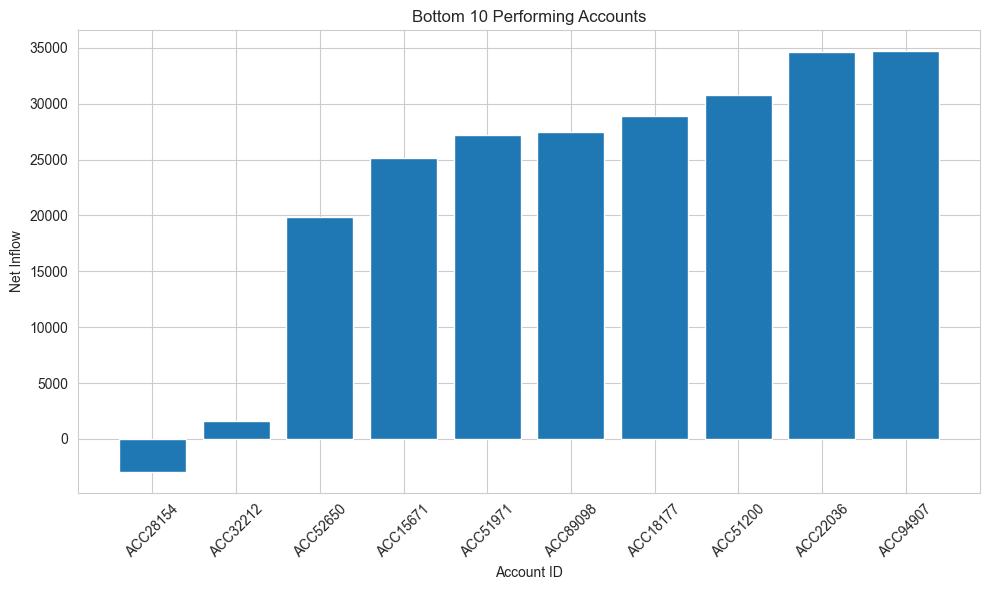

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    bottom_accounts["AccountID"],
    bottom_accounts["TransactionAmount"]
)

plt.xticks(rotation=45)

plt.title("Bottom 10 Performing Accounts")

plt.xlabel("Account ID")

plt.ylabel("Net Inflow")

plt.tight_layout()

plt.savefig(
    "Images/bottom_performing_accounts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

These accounts have the lowest net inflow, indicating limited deposits or higher spending compared to inflows. Such accounts may require closer monitoring or targeted customer engagement strategies.

### Dormant or Inactive Accounts

##### Dormancy Criteria:

An account is considered dormant if the gap between two consecutive transactions is **60 days or more**.
This criterion has been defined as per the project instructions.

In [ ]:
# Sort data by AccountID and TransactionDate
df = df.sort_values(["AccountID", "TransactionDate"])

# Calculate gap between consecutive transactions
df["GapDays"] = (
    df.groupby("AccountID")["TransactionDate"]
      .diff()
      .dt.days
)

# Find dormant transactions (gap >= 60 days)
dormant_accounts = df[df["GapDays"] >= 60]

dormant_accounts["AccountID"].nunique()

dormant_accounts.head()



,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,TransactionCategory,GapDays
681,76,CUST6735,ACC10117,Loan,Payment,Credit Card,Firm D,North,Manager 1,2023-11-08,83158.65148,110937.57410,0.609497,687,236,2023-11,2023,Debit,160.0
41,112,CUST8091,ACC10117,Loan,Deposit,Personal Loan,Firm A,West,Manager 2,2024-04-06,54168.90233,97023.17014,0.720880,400,148,2024-04,2024,Credit,150.0
265,72,CUST7002,ACC10117,Savings,Deposit,Mutual Fund,Firm B,North,Manager 2,2024-06-22,60877.05837,89254.12450,0.495491,586,93,2024-06,2024,Credit,77.0
585,72,CUST3041,ACC10996,Savings,Payment,Savings Account,Firm E,North,Manager 4,2023-10-16,77860.86889,66344.39469,0.670691,667,232,2023-10,2023,Debit,272.0
59,64,CUST9038,ACC10996,Savings,Withdrawal,Personal Loan,Firm C,West,Manager 1,2024-01-01,70136.96717,25464.12779,0.579622,797,217,2024-01,2024,Debit,74.0


In [ ]:
dormant_accounts.to_csv(
    "Output/Dormant_Accounts.csv",
    index=False
)

print("Dormant accounts saved successfully.")

Dormant accounts saved successfully.


### Task 2 Summary

- Monthly and yearly transaction summaries were prepared.
- Credit and debit transaction trends were analyzed.
- Top-performing and bottom-performing accounts were identified based on net inflow.
- Dormant accounts were detected using a 60-day inactivity criterion.
- All outputs were saved for reporting and further analysis.

# Task 3: Customer Profile Building

### Customer Activity Rubric

The customer activity levels are defined based on the total number of transactions performed by each account.

#### Rubric Used

- High Activity : More than 7 transactions
- Medium Activity : 4 to 7 transactions
- Low Activity : Less than 4 transactions


### Transaction Frequency for Each Account

In [ ]:
transaction_frequency = (
    df.groupby("AccountID")
      .size()
      .reset_index(name="TransactionFrequency")
)

transaction_frequency.head()

,AccountID,TransactionFrequency
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,4
4,ACC11285,3


### Customer Activity Levels

In [ ]:
def activity_level(x):

    if x > 7:
        return "High"

    elif x >= 4:
        return "Medium"

    else:
        return "Low"


transaction_frequency["ActivityLevel"] = (
    transaction_frequency["TransactionFrequency"]
    .apply(activity_level)
)

transaction_frequency.head()

,AccountID,TransactionFrequency,ActivityLevel
0,ACC10117,4,Medium
1,ACC10996,5,Medium
2,ACC11062,2,Low
3,ACC11188,4,Medium
4,ACC11285,3,Low


### Activity Level Distribution

In [ ]:
transaction_frequency["ActivityLevel"].value_counts()

ActivityLevel
Medium    107
Low        72
High       14
Name: count, dtype: int64

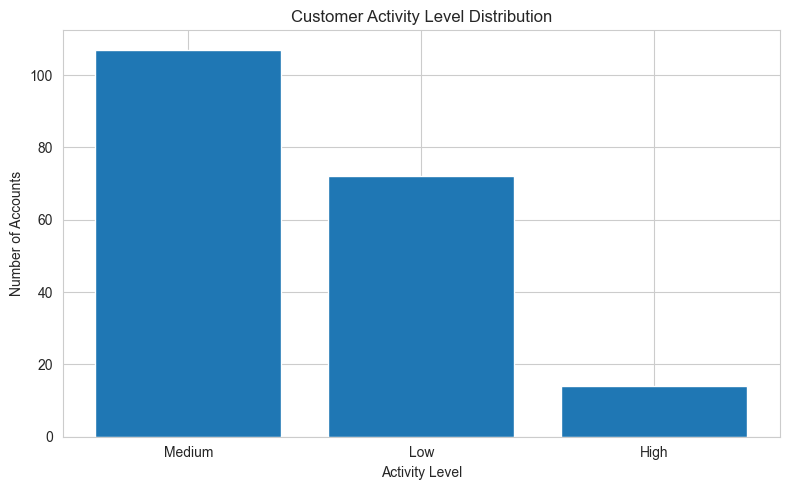

In [ ]:
plt.figure(figsize=(8,5))

activity_counts = transaction_frequency["ActivityLevel"].value_counts()

plt.bar(
    activity_counts.index,
    activity_counts.values
)

plt.title("Customer Activity Level Distribution")

plt.xlabel("Activity Level")

plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.savefig(
    "Images/customer_activity_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The activity level distribution categorizes customer accounts into High, Medium, and Low activity groups based on transaction frequency. This segmentation helps identify highly engaged customers and customers who may require re-engagement strategies.

### Average Account Balance

In [ ]:
average_balance = (
    df.groupby("AccountID")["AccountBalance"]
      .mean()
      .reset_index()
)

average_balance.head()

,AccountID,AccountBalance
0,ACC10117,97828.704775
1,ACC10996,56982.152538
2,ACC11062,65947.316965
3,ACC11188,81169.114065
4,ACC11285,62574.613950


### Customers by Average Balance

In [ ]:
q1 = average_balance["AccountBalance"].quantile(0.33)

q2 = average_balance["AccountBalance"].quantile(0.66)


def balance_segment(balance):

    if balance <= q1:
        return "Low Balance"

    elif balance <= q2:
        return "Medium Balance"

    else:
        return "High Balance"


average_balance["BalanceSegment"] = (
    average_balance["AccountBalance"]
    .apply(balance_segment)
)

average_balance.head()

,AccountID,AccountBalance,BalanceSegment
0,ACC10117,97828.704775,High Balance
1,ACC10996,56982.152538,Low Balance
2,ACC11062,65947.316965,Low Balance
3,ACC11188,81169.114065,High Balance
4,ACC11285,62574.613950,Low Balance


### Balance Segment Distribution

In [ ]:
average_balance["BalanceSegment"].value_counts()

BalanceSegment
High Balance      66
Low Balance       64
Medium Balance    63
Name: count, dtype: int64

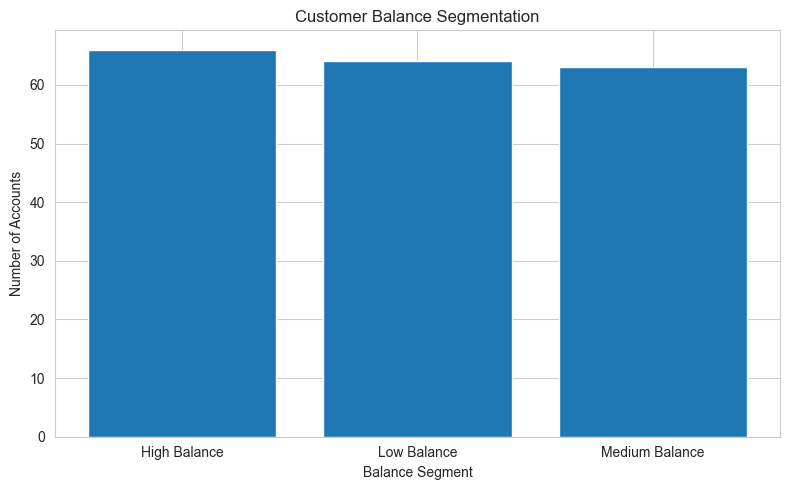

In [ ]:
plt.figure(figsize=(8,5))

balance_counts = average_balance["BalanceSegment"].value_counts()

plt.bar(
    balance_counts.index,
    balance_counts.values
)

plt.title("Customer Balance Segmentation")

plt.xlabel("Balance Segment")

plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.savefig(
    "Images/balance_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Customers are grouped into Low, Medium, and High Balance categories. This allows Barclays to identify customers with stronger financial positions and tailor banking services accordingly.

### Transaction Volume for Each Account

Transaction volume represents the total monetary value of transactions performed by each account during the analysis period.

In [ ]:
transaction_volume = (
    df.groupby("AccountID")["TransactionAmount"]
      .sum()
      .reset_index()
)

transaction_volume.head()

,AccountID,TransactionAmount
0,ACC10117,238427.20992
1,ACC10996,269471.35221
2,ACC11062,110594.78398
3,ACC11188,225517.45894
4,ACC11285,236119.54601


### Customers by Transaction Volume

In [ ]:
q1 = transaction_volume["TransactionAmount"].quantile(0.33)
q2 = transaction_volume["TransactionAmount"].quantile(0.66)

def volume_segment(x):

    if x <= q1:
        return "Low Volume"

    elif x <= q2:
        return "Medium Volume"

    else:
        return "High Volume"

transaction_volume["TransactionVolumeSegment"] = (
    transaction_volume["TransactionAmount"]
    .apply(volume_segment)
)

transaction_volume.head()

,AccountID,TransactionAmount,TransactionVolumeSegment
0,ACC10117,238427.20992,Medium Volume
1,ACC10996,269471.35221,High Volume
2,ACC11062,110594.78398,Low Volume
3,ACC11188,225517.45894,Medium Volume
4,ACC11285,236119.54601,Medium Volume


### Transaction Volume Distribution

In [ ]:
transaction_volume["TransactionVolumeSegment"].value_counts()

TransactionVolumeSegment
High Volume      66
Low Volume       64
Medium Volume    63
Name: count, dtype: int64

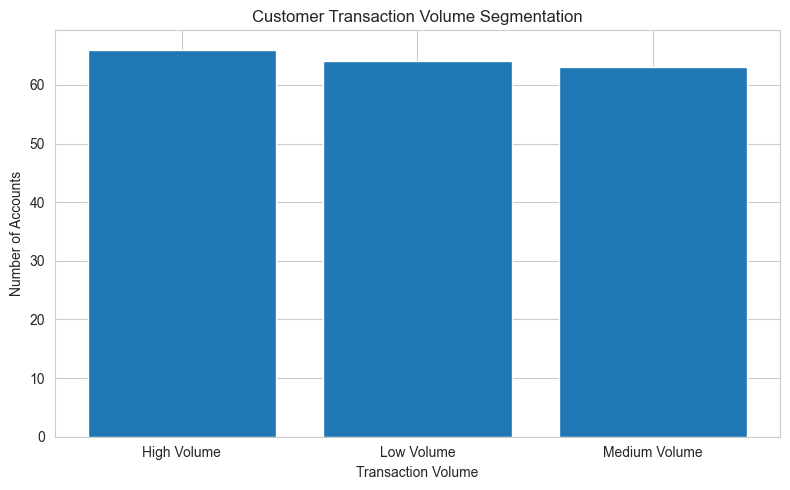

In [ ]:
plt.figure(figsize=(8,5))

volume_counts = transaction_volume["TransactionVolumeSegment"].value_counts()

plt.bar(
    volume_counts.index,
    volume_counts.values
)

plt.title("Customer Transaction Volume Segmentation")

plt.xlabel("Transaction Volume")

plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.savefig(
    "Images/transaction_volume_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Transaction volume segmentation identifies customers with high monetary transaction activity. These customers contribute significantly to the bank's overall transaction value and may benefit from personalized financial products.

### High Net Inflow Accounts

In [ ]:
high_net_inflow = (
    transaction_volume
    .sort_values("TransactionAmount", ascending=False)
    .head(10)
)

high_net_inflow

,AccountID,TransactionAmount,TransactionVolumeSegment
109,ACC54589,720103.595590,High Volume
180,ACC92558,645089.102250,High Volume
97,ACC49422,564943.533450,High Volume
156,ACC80131,556260.453470,High Volume
79,ACC42710,552578.283770,High Volume
20,ACC19178,538885.526270,High Volume
165,ACC83581,507631.685320,High Volume
181,ACC94203,493355.012822,High Volume
151,ACC77773,476188.652680,High Volume
59,ACC32890,450092.904840,High Volume


In [ ]:
high_net_inflow.to_csv(
    "Output/High_Net_Inflow_Accounts.csv",
    index=False
)

print("High net inflow accounts saved successfully.")

High net inflow accounts saved successfully.


### High-Frequency Low-Balance Accounts

#### Criteria Used

Accounts having:

- Medium or High Activity
- Low Balance

In [ ]:
high_frequency_low_balance = (
    transaction_frequency.merge(
        average_balance,
        on="AccountID"
    )
)

high_frequency_low_balance = high_frequency_low_balance[
    (
        high_frequency_low_balance["ActivityLevel"].isin(
            ["High", "Medium"]
        )
    )
    &
    (
        high_frequency_low_balance["BalanceSegment"] == "Low Balance"
    )
]

high_frequency_low_balance.head()

,AccountID,TransactionFrequency,ActivityLevel,AccountBalance,BalanceSegment
1,ACC10996,5,Medium,56982.152538,Low Balance
7,ACC12334,5,Medium,58469.937674,Low Balance
13,ACC16241,5,Medium,55945.625702,Low Balance
19,ACC19156,4,Medium,64046.130650,Low Balance
22,ACC21264,5,Medium,62025.190430,Low Balance


In [ ]:
high_frequency_low_balance.to_csv(
    "Output/High_Frequency_Low_Balance.csv",
    index=False
)

print("High-frequency low-balance accounts saved successfully.")

High-frequency low-balance accounts saved successfully.


### Accounts with Negative or Near-Zero Balance

In [ ]:
negative_balance_accounts = average_balance[
    average_balance["AccountBalance"] <= 0
]

negative_balance_accounts

,AccountID,AccountBalance,BalanceSegment


In [ ]:
negative_balance_accounts.to_csv(
    "Output/Negative_Balance_Accounts.csv",
    index=False
)

print("Negative/Near-zero balance accounts saved successfully.")

Negative/Near-zero balance accounts saved successfully.


### Task 3 Summary

- Customers were classified into High, Medium, and Low activity groups based on transaction frequency.
- Customers were segmented into Low, Medium, and High Balance categories using percentile-based thresholds.
- Transaction volume segmentation was performed to identify customers with high monetary activity.
- High net inflow accounts were identified.
- High-frequency low-balance accounts were highlighted for possible financial advisory or engagement.
- Accounts with negative or near-zero balances were identified for closer monitoring and targeted banking support.

# Task 4: Financial Risk Identification

### Accounts with Frequent Large Withdrawals

#### Criteria Used

A withdrawal is considered **large** if its transaction amount is greater than or equal to the 75th percentile (Q3) of all withdrawal transactions.

This data-driven criterion avoids using arbitrary thresholds.

In [ ]:
withdrawals = df[df["TransactionType"] == "Withdrawal"].copy()

large_withdrawal_threshold = withdrawals["TransactionAmount"].quantile(0.75)

print("Large Withdrawal Threshold:", large_withdrawal_threshold)

Large Withdrawal Threshold: 75853.667085


In [ ]:
large_withdrawals = withdrawals[
    withdrawals["TransactionAmount"] >= large_withdrawal_threshold
]

frequent_large_withdrawals = (
    large_withdrawals.groupby("AccountID")
    .size()
    .reset_index(name="LargeWithdrawalCount")
    .sort_values("LargeWithdrawalCount", ascending=False)
)

frequent_large_withdrawals.head(10)

,AccountID,LargeWithdrawalCount
2,ACC19178,2
24,ACC45521,2
25,ACC49140,2
17,ACC35163,2
15,ACC34568,2
33,ACC65144,2
29,ACC51593,2
30,ACC54589,2
5,ACC21429,1
0,ACC12334,1


In [ ]:
frequent_large_withdrawals.to_csv(
    "Output/Frequent_Large_Withdrawals.csv",
    index=False
)

print("Frequent large withdrawal report saved successfully.")

Frequent large withdrawal report saved successfully.


Accounts with repeated large withdrawals may indicate higher financial risk or unusual spending behavior. These accounts can be monitored more closely for risk management.

### Overdraft Accounts

Accounts having a negative account balance are treated as overdraft accounts.

In [ ]:
overdraft_accounts = df[df["AccountBalance"] < 0]

overdraft_accounts.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,TransactionCategory,GapDays
236,99,CUST4584,ACC11285,Credit,Payment,Mutual Fund,Firm D,West,Manager 1,2024-03-30,88130.72313,-17751.216810,0.812135,724,30,2024-03,2024,Debit,410.0
217,59,CUST4855,ACC19156,Credit,Payment,Personal Loan,Firm B,North,Manager 3,2023-10-26,56937.62473,-9649.975980,0.310960,688,11,2023-10,2023,Debit,20.0
89,165,CUST8279,ACC21264,Credit,Withdrawal,Personal Loan,Firm D,South,Manager 1,2023-02-14,81999.94967,-8247.315181,0.531051,624,239,2023-02,2023,Debit,NaN
359,171,CUST5545,ACC24880,Savings,Deposit,Mutual Fund,Firm A,North,Manager 2,2024-03-28,44410.00366,-5199.930807,0.591813,495,156,2024-03,2024,Credit,154.0
392,14,CUST5255,ACC32890,Credit,Deposit,Credit Card,Firm B,West,Manager 4,2023-01-15,40011.57645,-800.699930,0.130483,829,64,2023-01,2023,Credit,NaN


#### Total Number of Overdraft Accounts

In [ ]:
overdraft_accounts["AccountID"].nunique()

14

In [ ]:
overdraft_accounts.to_csv(
    "Output/Overdraft_Accounts.csv",
    index=False
)

print("Overdraft report saved successfully.")

Overdraft report saved successfully.


Negative account balances indicate overdraft situations. These customers may require financial monitoring or credit risk assessment.

### Calculate Balance Volatility

Balance volatility is measured using the standard deviation of account balances for each account. A higher standard deviation indicates greater fluctuations in account balance over time.

In [ ]:
balance_volatility = (
    df.groupby("AccountID")["AccountBalance"]
    .std()
    .reset_index(name="BalanceStdDev")
)

balance_volatility.head()

,AccountID,BalanceStdDev
0,ACC10117,9308.031969
1,ACC10996,18946.737199
2,ACC11062,22572.552392
3,ACC11188,20160.417506
4,ACC11285,70126.826097


In [ ]:
balance_volatility.to_csv(
    "Output/Balance_Volatility.csv",
    index=False
)

print("Balance volatility report saved successfully.")

Balance volatility report saved successfully.


### Transaction Amount Anomalies Using the IQR Method

The Interquartile Range (IQR) method is used to detect unusually high or low transaction amounts.

Criteria:

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Transactions outside these limits are considered anomalies.

In [ ]:
Q1 = df["TransactionAmount"].quantile(0.25)
Q3 = df["TransactionAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Lower Limit : -27901.9156975
Upper Limit : 135395.3414025


#### Anomalous Transactions

In [ ]:
anomalies = df[
    (df["TransactionAmount"] < lower_limit) |
    (df["TransactionAmount"] > upper_limit)
]

anomalies.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,TransactionCategory,GapDays
312,167,CUST9843,ACC21264,Current,Transfer,Home Loan,Firm C,East,Manager 2,2023-06-20,149404.33020,71076.77650,0.371491,769,61,2023-06,2023,Debit,126.0
200,169,CUST2188,ACC40939,Loan,Payment,Mutual Fund,Firm C,Central,Manager 2,2024-03-12,-29124.62485,70433.48821,0.695776,594,141,2024-03,2024,Debit,267.0
622,12,CUST1121,ACC43309,Credit,Transfer,Savings Account,Firm B,South,Manager 1,2023-10-16,166083.82960,69875.76042,0.708081,372,230,2023-10,2023,Debit,35.0
48,6,CUST2427,ACC80131,Current,Deposit,Mutual Fund,Firm C,South,Manager 1,2023-11-19,141600.74000,58800.35045,0.130982,313,168,2023-11,2023,Credit,11.0
6,14,CUST5558,ACC82947,Credit,Payment,Credit Card,Firm A,East,Manager 2,2023-09-26,-43698.75917,124963.76370,0.460877,433,110,2023-09,2023,Debit,53.0


In [ ]:
print(" Total Number of Anomalous Transactions:",len(anomalies))


 Total Number of Anomalous Transactions: 7


In [ ]:
anomalies.to_csv(
    "Output/Transaction_Anomalies.csv",
    index=False
)

print("Transaction anomaly report saved successfully.")

Transaction anomaly report saved successfully.


Transactions identified using the IQR method fall significantly outside the normal transaction range. These transactions may require further investigation to determine whether they represent genuine customer activity or unusual financial behavior.

### Customers with Suspicious Transaction Behaviour

For this project, an account is considered suspicious if **any** of the following conditions are met:

- Frequent large withdrawals
- Negative account balance (overdraft)
- Presence of anomalous transactions

This combined approach provides a comprehensive view of financial risk.

In [ ]:
suspicious_accounts = set(frequent_large_withdrawals["AccountID"]) | \
                      set(overdraft_accounts["AccountID"]) | \
                      set(anomalies["AccountID"])

suspicious_accounts = pd.DataFrame(
    sorted(suspicious_accounts),
    columns=["AccountID"]
)

suspicious_accounts.head()

,AccountID
0,ACC11285
1,ACC12334
2,ACC17688
3,ACC19156
4,ACC19178


In [ ]:
print("Total Suspicious Accounts:",len(suspicious_accounts))

Total Suspicious Accounts: 57


In [ ]:
suspicious_accounts.to_csv(
    "Output/Suspicious_Accounts.csv",
    index=False
)

print("Suspicious account report saved successfully.")

Suspicious account report saved successfully.


### Task 4 Summary

- Large withdrawal accounts were identified using the 75th percentile threshold.
- Overdraft accounts were detected using negative account balances.
- Balance volatility was measured using standard deviation.
- Transaction anomalies were detected using the IQR method.
- Customers with suspicious financial behaviour were identified by combining multiple financial risk indicators.

# Task 5: Visualisation

### Distribution of Transaction Amount

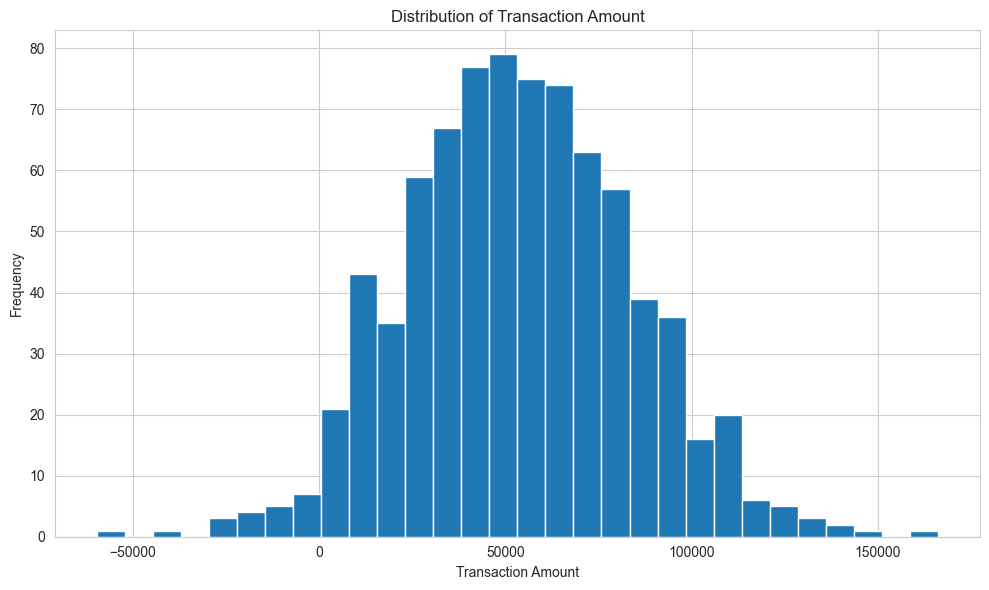

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["TransactionAmount"],
    bins=30
)

plt.title("Distribution of Transaction Amount")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "Images/transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The histogram shows how transaction amounts are distributed. It helps identify whether most customer transactions are of low, medium, or high value and highlights the presence of extreme transactions.

### Distribution of Account Balance

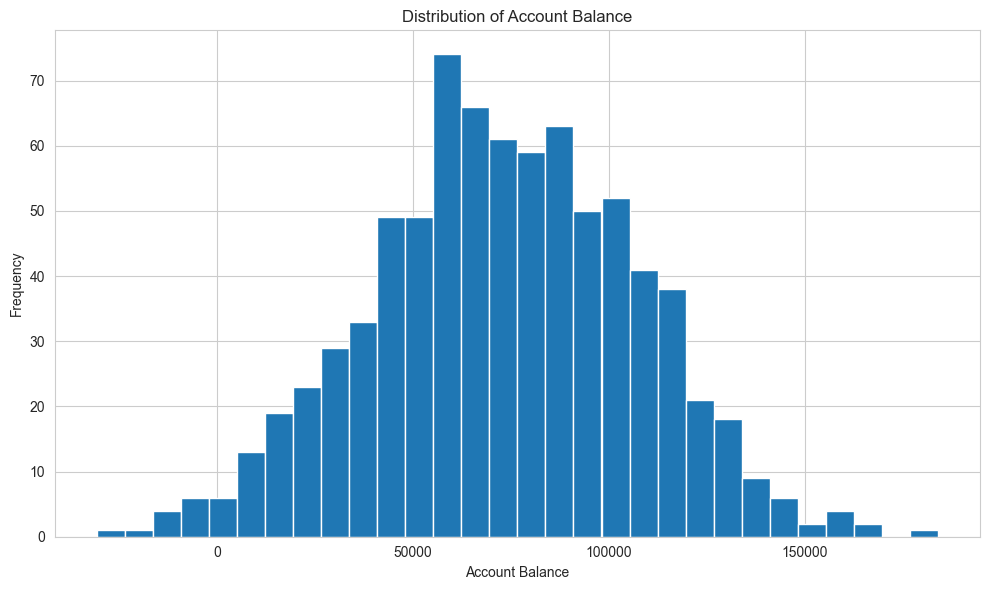

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["AccountBalance"],
    bins=30
)

plt.title("Distribution of Account Balance")

plt.xlabel("Account Balance")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "Images/account_balance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The account balance distribution helps identify whether customer balances are concentrated within a specific range and whether any accounts have unusually low or high balances.

### Transaction Amount by Account Type

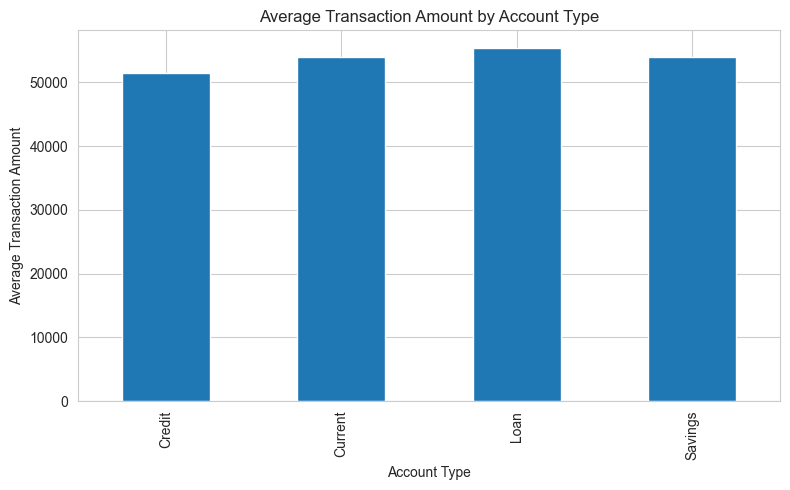

In [ ]:
plt.figure(figsize=(8,5))

df.groupby("AccountType")["TransactionAmount"].mean().plot(
    kind="bar"
)

plt.title("Average Transaction Amount by Account Type")

plt.xlabel("Account Type")

plt.ylabel("Average Transaction Amount")

plt.tight_layout()

plt.savefig(
    "Images/accounttype_transaction_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

This chart compares the average transaction amount across different account types, helping identify which account categories generate higher-value transactions.

### Average Risk Score by Region

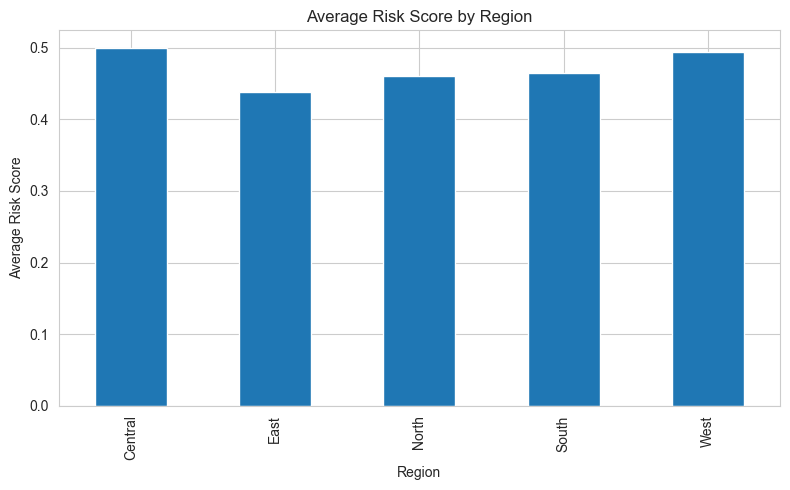

In [ ]:
plt.figure(figsize=(8,5))

df.groupby("Region")["RiskScore"].mean().plot(
    kind="bar"
)

plt.title("Average Risk Score by Region")

plt.xlabel("Region")

plt.ylabel("Average Risk Score")

plt.tight_layout()

plt.savefig(
    "Images/riskscore_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

This visualization highlights regional differences in average financial risk and may help Barclays focus risk management efforts where risk scores are comparatively higher.

### Credit Rating Distribution

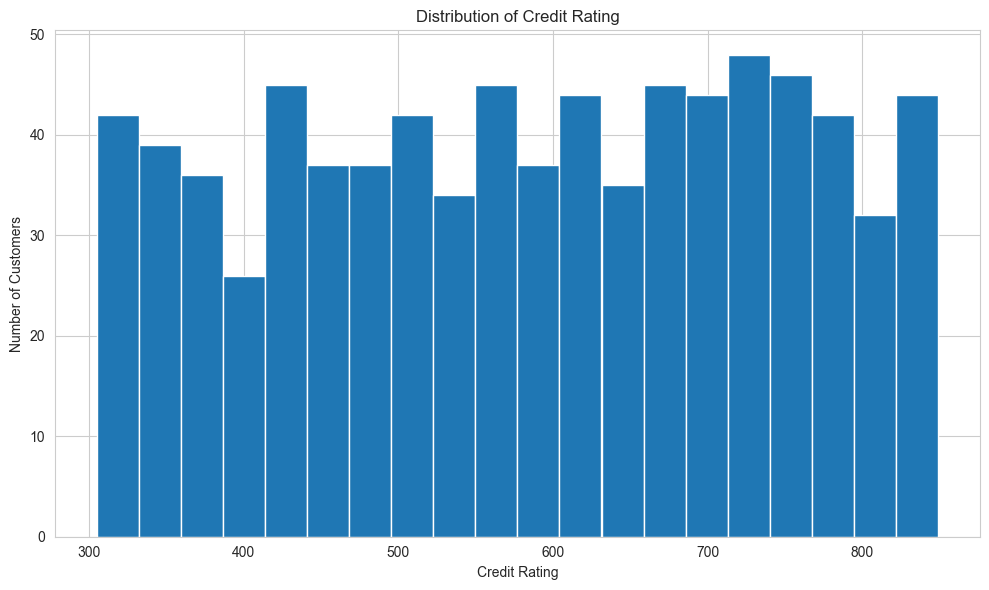

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["CreditRating"],
    bins=20
)

plt.title("Distribution of Credit Rating")

plt.xlabel("Credit Rating")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "Images/credit_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The distribution of credit ratings helps understand the overall credit quality of customers and supports risk assessment strategies.

### Task 5 Summary

- Transaction amount distribution was analyzed.
- Account balance distribution was visualized.
- Average transaction amount was compared across account types.
- Regional variation in risk score was explored.
- Customer credit rating distribution was examined.

These visualizations complement the charts developed in previous tasks and provide additional insights into customer behavior and financial risk.

# Task 6: Hypothesis Testing 

The objective of this task is to statistically test whether customer transaction behaviour is associated with account balances and customer segmentation.

We will perform two hypothesis tests:

1. Test whether high-volume transaction accounts have statistically higher average balances than low-volume transaction accounts.

2. Test whether average account balances differ significantly among customer activity level segments.

### Test Whether High Transaction Volume Accounts Have Higher Average Balances

#### Null Hypothesis (H₀)

There is no significant difference in average account balance between High Transaction Volume and Low Transaction Volume accounts.

#### Alternative Hypothesis (H₁)

High Transaction Volume accounts have significantly higher average account balances than Low Transaction Volume accounts.

In [ ]:
from scipy.stats import ttest_ind

### Dataset for Hypothesis Testing

In [ ]:
hypothesis_df = average_balance.merge(
    transaction_volume[
        ["AccountID", "TransactionVolumeSegment"]
    ],
    on="AccountID"
)

hypothesis_df.head()

,AccountID,AccountBalance,BalanceSegment,TransactionVolumeSegment
0,ACC10117,97828.704775,High Balance,Medium Volume
1,ACC10996,56982.152538,Low Balance,High Volume
2,ACC11062,65947.316965,Low Balance,Low Volume
3,ACC11188,81169.114065,High Balance,Medium Volume
4,ACC11285,62574.613950,Low Balance,Medium Volume


### Separate High and Low Transaction Volume Accounts

In [ ]:
high_volume = hypothesis_df[
    hypothesis_df["TransactionVolumeSegment"] == "High Volume"
]["AccountBalance"]

low_volume = hypothesis_df[
    hypothesis_df["TransactionVolumeSegment"] == "Low Volume"
]["AccountBalance"]

### Perform Independent t-Test

In [ ]:
t_stat, p_value = ttest_ind(
    high_volume,
    low_volume,
    equal_var=False
)

print("T Statistic :", round(t_stat,4))
print("P Value :", round(p_value,4))

T Statistic : -0.553
P Value : 0.5813


### Conclusion

In [ ]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in average account balances between High and Low Transaction Volume accounts.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference in average account balances between High and Low Transaction Volume accounts.")

Fail to Reject the Null Hypothesis
There is no statistically significant difference in average account balances between High and Low Transaction Volume accounts.


The t-test determines whether customers with high transaction volume maintain significantly different account balances compared to customers with low transaction volume. This helps Barclays understand whether highly active customers also tend to maintain larger balances.

### Hypothesis Testing Based on Customer Activity Levels

#### Null Hypothesis (H₀)

The average account balance is the same across High, Medium, and Low Activity accounts.

#### Alternative Hypothesis (H₁)

At least one activity group has a significantly different average account balance.

In [ ]:
from scipy.stats import f_oneway

### Data for ANOVA Test

In [ ]:
anova_df = average_balance.merge(
    transaction_frequency[
        ["AccountID", "ActivityLevel"]
    ],
    on="AccountID"
)

anova_df.head()

,AccountID,AccountBalance,BalanceSegment,ActivityLevel
0,ACC10117,97828.704775,High Balance,Medium
1,ACC10996,56982.152538,Low Balance,Medium
2,ACC11062,65947.316965,Low Balance,Low
3,ACC11188,81169.114065,High Balance,Medium
4,ACC11285,62574.613950,Low Balance,Low


### Separate Groups

In [ ]:
high = anova_df[
    anova_df["ActivityLevel"] == "High"
]["AccountBalance"]

medium = anova_df[
    anova_df["ActivityLevel"] == "Medium"
]["AccountBalance"]

low = anova_df[
    anova_df["ActivityLevel"] == "Low"
]["AccountBalance"]

### Perform ANOVA Test

In [ ]:
f_stat, p_value = f_oneway(
    high,
    medium,
    low
)

print("F Statistic :", round(f_stat,4))
print("P Value :", round(p_value,4))

F Statistic : 0.5957
P Value : 0.5522


### Conclusion

In [ ]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("Average account balances differ significantly across High, Medium and Low Activity groups.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference in average account balances across High, Medium and Low Activity groups.")

Fail to Reject the Null Hypothesis
There is no statistically significant difference in average account balances across High, Medium and Low Activity groups.


### Task 6 Summary

- An independent t-test was conducted to compare average balances between High and Low Transaction Volume accounts.
- A one-way ANOVA test was performed to compare average balances across High, Medium, and Low Activity groups.
- Statistical conclusions were drawn based on a 5% significance level (α = 0.05).

# Key Findings

### Data Cleaning

- Financial data was cleaned and standardized.
- Date formats were validated.
- Transaction categories were standardized.

### Transaction Analysis

- Monthly and yearly transaction summaries were generated.
- Credit and Debit transaction trends were analyzed.
- Top and Bottom performing accounts were identified.
- Dormant accounts were detected.

### Customer Profile

- Customers were classified into High, Medium and Low Activity groups.
- Customers were segmented by Average Balance.
- Customers were segmented by Transaction Volume.
- High Net Inflow accounts were identified.
- High Frequency Low Balance accounts were identified.
- Negative Balance accounts were identified.

### Financial Risk

- Accounts with frequent large withdrawals were detected.
- Overdraft accounts were identified.
- Balance volatility was calculated.
- Transaction anomalies were detected using the IQR method.
- Suspicious accounts were highlighted.

### Hypothesis Testing

- Independent t-test was performed.
- One-way ANOVA test was performed.
- Both tests indicated that there was no statistically significant difference in average account balances across the compared customer groups.

### Recommendations

- Closely monitor overdraft accounts.
- Investigate accounts with frequent large withdrawals.
- Monitor anomalous transactions for fraud prevention.
- Provide personalized banking services for high-value customers.